# CSED 504 — A1 Computer Vision: Training CIFAR-10 (the standard way)

In the *hello_image* notebook we built a Vision Transformer **by hand** — patch embedding,
attention blocks, the forward pass, all spelled out. That is the right way to *learn* what a
model is doing. But it is not how you actually train an image classifier day-to-day.

This notebook shows the **standard, idiomatic PyTorch workflow** for CIFAR-10. Nothing here is
new *conceptually* — **you have already implemented essentially all of it by hand in CSED 502.**
What changes is that each hand-written piece gets replaced by the library function that does the
same thing, faster and with fewer bugs.

## Where the old code lives

Throughout, the comments cite the CSED 502 file that each PyTorch call is replacing. Most of the
NumPy machinery lives in one directory of your 502 coursework:

```
assignment3/csed502/
    layers.py       affine/relu/conv/pool/batchnorm/dropout forward + backward, softmax_loss
    optim.py        sgd, sgd_momentum, rmsprop, adam
    solver.py       Solver -- the training loop, LR decay, checkpointing
    data_utils.py   get_CIFAR10_data
    classifiers/    ThreeLayerConvNet (cnn.py), FullyConnectedNet (fc_net.py)
```

with two more we'll point at: `assignment4/PyTorch.ipynb` (the first time you used a `DataLoader`
and wrote a `zero_grad / backward / step` loop) and `assignment5/csed502/simclr/` (ResNet surgery,
augmentation, `state_dict` saving).

Line numbers refer to the assignment starter code, so they should line up with your own checkout.
These are pointers for **reading** — open them beside this notebook. Nothing here depends on them;
the notebook is self-contained.

## You already wrote all of this

The whole point of CSED 502's NumPy assignments was to make these boxes non-magical. Every row is
something you implemented, and the tool that now stands in for it:

| Job | What you wrote in CSED 502 | Standard tool |
|-----|----------------------------|---------------|
| Load + preprocess CIFAR-10 | `get_CIFAR10_data` (`data_utils.py:48`) — unpickle, subtract the mean image, transpose to NCHW | `torchvision.datasets.CIFAR10` |
| Normalize inputs | `X -= mean_image` (`data_utils.py:73-77`) — per-pixel, no std | `transforms.Normalize` (per-channel mean **and** std) |
| Batch & shuffle | `Solver._step` (`solver.py:169`) — `np.random.choice(num_train, batch_size)` | `torch.utils.data.DataLoader` |
| Conv layer | `conv_forward_naive` (`layers.py:1403`), then the im2col speedup (`im2col.py`, `fast_layers.py`) | `nn.Conv2d` (cuDNN does im2col for you) |
| Pooling, ReLU, BatchNorm | `max_pool_forward_naive` (`:1606`), `relu_forward` (`:135`), `spatial_batchnorm_forward` (`:1773`) | `nn.MaxPool2d`, `nn.ReLU`, `nn.BatchNorm2d` |
| Assembling a CNN | `ThreeLayerConvNet` (`cnn.py:9`) — a flat `self.params` dict, hand-chained forward/backward | `torchvision.models.resnet18` |
| The backward pass | every `*_backward(dout, cache)` in `layers.py` that you derived and gradient-checked | **autograd** — `loss.backward()` |
| Loss | `softmax_loss` (`layers.py:345`) → returns `(loss, dx)` | `nn.CrossEntropyLoss` |
| L2 regularization | `loss += 0.5 * reg * np.sum(W**2)` (`cnn.py:212`) | `weight_decay=` on the optimizer |
| Update rule | `sgd_momentum` (`optim.py:48`) — `v = rho*v - lr*dw; w += v` | `torch.optim.SGD(momentum=...)` |
| Training loop | `Solver.train()` (`solver.py:254`) — iterations, LR decay, `check_accuracy`, `best_params` | *still yours* — see §4 |

The three things below that you have **not** seen before, in either 502 or 503, are called out
where they appear: the **LR scheduler** (§3), **mixed precision** (§3), and **`RandomCrop`
augmentation** (§1). Everything else is a renaming exercise.

> **Note on CSED 503:** 503 was NLP, so none of the vision stack came up there. The last time you
> touched `DataLoader` / `torchvision` was **CSED 502 assignment 4** (`PyTorch.ipynb`), and that is
> also the last time you wrote `zero_grad / backward / step` yourself — in 503 the optimizer step
> was always hidden inside minGPT's `Trainer` or HuggingFace's. If those feel rusty, that is why.

The pattern below — **transforms → dataset → loader → model → loss/optimizer → epoch loop of
train + evaluate** — is the same skeleton you'll reuse for almost any supervised vision task.
Swap the dataset and the model and everything else stays put. It is also, structurally, exactly
what `Solver` did: `Solver._step()` is the inner batch loop and `Solver.train()` is the outer
epoch loop.

---
**Running this notebook:** it needs no other files — just a Python environment with PyTorch. On
**Google Colab**, open it, set **Runtime → Change runtime type → GPU**, and run all cells; the
first cell installs anything missing and CIFAR-10 downloads itself.


In [1]:
# Install required packages.  If you're running in the uw-csed504 conda environment these
# are already installed and this is a no-op.  For Colab or fresh setups it will pull them in.
%pip install --quiet torch torchvision numpy matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# -- 1. Device detection + reproducible seeds -------------------------------------------------------
# Pick the best device available -- CUDA (NVIDIA) -> MPS (Apple Silicon) -> CPU -- and lock the RNGs
# so runs are repeatable.  Nothing here is CIFAR-specific; it is the boilerplate every PyTorch
# notebook opens with.  (No 502 counterpart: NumPy is CPU-only, so there was no device to choose.)
import os, random, warnings
import torch
import numpy as np

# MPS (Apple Silicon) compatibility: PYTORCH_ENABLE_MPS_FALLBACK catches forward ops that aren't
# implemented on MPS and reroutes them to CPU.  It does NOT help with backward pass errors, which
# come from the C++ autograd engine and aren't intercepted by this mechanism.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

# Suppress a spurious 'Failed to load image Python extension: libjpeg.9.dylib' UserWarning that
# torchvision.io emits on macOS when libjpeg.9 isn't installed.  We never use torchvision.io --
# CIFAR-10 loads from pickles, not JPEG files -- so this is harmless noise.
#
# Two lines are needed because DataLoader workers are spawned as fresh Python processes on macOS
# (the 'spawn' start method), so they don't inherit warnings.filterwarnings state from the parent.
# PYTHONWARNINGS is an environment variable that Python reads on startup, so it DOES propagate.
# The filterwarnings call silences it in the main process; PYTHONWARNINGS silences it in workers.
warnings.filterwarnings('ignore', message='Failed to load image Python extension',
                        category=UserWarning, module='torchvision.io.image')
os.environ.setdefault('PYTHONWARNINGS', 'ignore::UserWarning:torchvision.io.image')

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Device: CUDA -- {torch.cuda.get_device_name(0)}')
    # Optional NVIDIA speedups: TF32 matmuls, and let cuDNN autotune its convolution algorithms.
    # Our input shape never changes, so that autotuning cost is paid once, on the first batch.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: MPS -- Apple Silicon GPU')
else:
    DEVICE = torch.device('cpu')
    print(f'Device: CPU ({os.cpu_count() or 1} cores) -- training will be slow.  Lower EPOCHS in §3.')

# VisionTransformer's backward pass uses .view() on non-contiguous tensors produced by MPS autograd.
# This crashes with:  RuntimeError: view size is not compatible with input tensor's size and stride
# The bug is in the C++ autograd engine (not patchable from Python) and is confirmed present through
# at least PyTorch 2.5.1.  The ResNet and all forward passes are completely unaffected -- only the
# ViT backward (i.e. training, not inference) triggers it.  VIT_DEVICE falls back to CPU for those
# runs; DEVICE (MPS) is used for the ResNet and for ViT forward-pass sanity checks.
VIT_DEVICE = torch.device('cpu') if DEVICE.type == 'mps' else DEVICE
if VIT_DEVICE != DEVICE:
    print(f'ViT device: CPU  (MPS autograd .view() bug -- ViT inference still runs on MPS fine)')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Seeds set to {SEED}')


Device: CUDA -- NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition
Seeds set to 42


In [3]:
import time
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output   # redraw the epoch log in place, so the per-batch bar never piles up
from tqdm import tqdm   # NOT tqdm.auto: in Jupyter that renders the progress bar as an
                       # ipywidget, and saving the notebook then serializes ~1 KB of widget
                       # state per bar into the file's metadata (100 epochs -> ~860 KB of
                       # junk in every git diff).  Plain tqdm prints a text bar instead.

print('torch', torch.__version__, '| torchvision', torchvision.__version__)


torch 2.11.0+cu128 | torchvision 0.26.0+cu128


## 1. Data — `transforms`, `datasets`, and `DataLoader`

**In CSED 502 this was one function you wrote:**
`get_CIFAR10_data()` (`data_utils.py:48`). It unpickled the
raw batches, sliced off a validation set, subtracted the mean image, transposed to NCHW, and handed
back a dict of NumPy arrays. Then `Solver` grabbed batches out
of it with `np.random.choice`.

PyTorch splits that same work across three objects, and the split is what lets you swap any one
piece without touching the others:

- **`transforms`** — the per-image preprocessing pipeline. This is the part of `get_CIFAR10_data`
  that did `X -= mean_image` and `X.transpose(0, 3, 1, 2)` (`data_utils.py:73-82`), except it runs
  **lazily, per image, as the image is loaded** instead of eagerly over the whole 50,000-image
  array. That laziness is what makes *augmentation* possible at all: for **training** we add a
  random crop and horizontal flip, so the model sees a slightly different version of each image
  every epoch. You couldn't do that with a preprocessed NumPy block — the augmentation has to
  happen fresh on every read. For **testing** we do not augment; we want a fixed, honest
  measurement.
- **`datasets.CIFAR10`** — the unpickling half of `get_CIFAR10_data`. Downloads the 60,000 32×32
  images (50k train / 10k test), caches them under `./data`, and applies the transform we hand it.
  You met this in **CSED 502 assignment 4** as `dset.CIFAR10(...)`
  (`PyTorch.ipynb`).
- **`DataLoader`** — replaces the batching in
  `Solver._step` (`solver.py:176`):
  `np.random.choice(num_train, self.batch_size)`. It hands us shuffled **batches**, optionally
  using worker processes to load and augment in parallel while the GPU is busy. (There is a real
  behavioral difference from `np.random.choice` — see the DataLoader cell below.)

One thing we're **not** doing that 502 did: carving out a validation split. `get_CIFAR10_data` took
`num_validation=1000` off the training set, and 502 A4 did the same with a
`sampler.SubsetRandomSampler`. Here we tune nothing, so we just train on all 50k and report test
accuracy. If you start tuning hyperparameters, put the val split back —
`torch.utils.data.random_split` is the modern way — because otherwise you are choosing
hyperparameters on your test set.

In [4]:
# CIFAR-10 per-channel mean and standard deviation over the 50,000 *training* images, in [0,1].
#
# WHERE THESE COME FROM: they are not published in the CIFAR-10 tech report (Krizhevsky 2009,
# https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf) -- they are just the dataset's own
# statistics, and anyone can recompute them.  The next cell does exactly that, so we don't have to
# take a number copied off the internet on faith.
#
# HOW THIS DIFFERS FROM CSED 502 -- read get_CIFAR10_data (assignment3/csed502/data_utils.py:48).
# It computed a per-PIXEL mean IMAGE (mean_image = np.mean(X_train, axis=0), shape (32,32,3): one
# number per pixel per channel) and subtracted it.  It never divided by a std at all.  Normalize()
# differs in two ways: (1) it is per-CHANNEL -- just 3 numbers, not 3072; (2) it also divides by
# std, so each channel comes out roughly zero-mean AND unit-variance.  The std divide is what puts
# all three channels on the same scale, so the loss surface is less elongated and one learning rate
# suits all of them.  Per-channel is the standard choice now: a mean image bakes in the average
# *composition* of the training photos (sky at the top, and so on), which doesn't generalize.
#
# CAREFUL -- you have seen a DIFFERENT std before.  CSED 502 assignment 4 (PyTorch.ipynb) used
#     T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
# The mean matches ours exactly; the std does not.  (0.2023, 0.1994, 0.2010) is a widely-copied
# value (it traces to the kuangliu/pytorch-cifar repo) that is NOT the true per-channel std over all
# pixels -- it is noticeably too small.  Run the next cell and you'll see the data disagree with it.
# Either one trains fine in practice, because normalization only has to be *consistent* between
# train and test -- it's a fixed affine rescale and the network learns around it.  But when a number
# is this easy to check, check it.  We use the values that actually come out of the data.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Training pipeline: augment, then tensor-ify and normalize.  Order matters -- the random ops run on
# the PIL image, and ToTensor/Normalize must come last.
#   RandomCrop(32, padding=4)  -- NEW; you have not used this one.  Pad 4px of zeros on each side to
#                                 make it 40x40, then crop a random 32x32 window back out.  Net
#                                 effect: the image is randomly shifted by up to 4px in each
#                                 direction, so the model can't memorize absolute pixel positions.
#                                 (502 A5's SimCLR used RandomResizedCrop, which rescales; this one
#                                 only translates.  See assignment5/csed502/simclr/data_utils.py.)
#   RandomHorizontalFlip()     -- mirror left<->right 50% of the time (a flipped cat is still a cat).
#                                 You used this one in 502 A5's SimCLR augmentation pipeline
#                                 (assignment5/csed502/simclr/data_utils.py).
#
# WHY BOTH: this is regularization, and it does the same job as the `reg` L2 term in your 502 models
# -- it fights overfitting -- but by a completely different mechanism.  L2 constrains the WEIGHTS;
# augmentation enlarges the DATA.  With ~11M parameters and only 50k images, a ResNet will otherwise
# drive training accuracy to 100% by memorizing.  Watch for it in the learning curves in section 6.
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                       # PIL image -> float tensor in [0,1], shape (C,H,W).
                                                 # This is the NHWC->NCHW `X.transpose(0, 3, 1, 2)`
                                                 # you did by hand (data_utils.py:80), plus the /255.
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD), # (x - mean) / std, per channel.  The moral
                                                 # equivalent of your `X -= mean_image`
                                                 # (data_utils.py:73), but per channel and with the
                                                 # std divide added.
])

# Test pipeline: NO augmentation -- just the deterministic tensor + normalize.  Note we normalize the
# test set with the TRAINING set's statistics, never its own.  Same discipline as 502, where
# get_CIFAR10_data computed mean_image from X_train and subtracted it from val and test too
# (data_utils.py:74-77): preprocessing constants are part of the model, and fitting them on test
# data leaks information about it.
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Datasets: download=True fetches CIFAR-10 into ./data on first run, then reuses the cache.  This is
# the unpickling that load_CIFAR10() did by hand (data_utils.py:26).
#
# NOTE the transform is attached to the DATASET, not the loader -- and the two datasets get
# different ones.  That's how "augment the train set but not the test set" is expressed here; in 502
# you'd have written an `if train:` somewhere.  Getting this backwards (augmenting at test time) is
# a classic bug that quietly costs you a point or two of accuracy.
train_set = datasets.CIFAR10(root='./data/cifar10', train=True,  download=(not os.path.isdir('./data/cifar10/cifar-10-batches-py')), transform=train_tf)
test_set  = datasets.CIFAR10(root='./data/cifar10', train=False, download=(not os.path.isdir('./data/cifar10/cifar-10-batches-py')), transform=test_tf)

CLASSES = train_set.classes   # ['airplane', 'automobile', 'bird', ... ] -- 10 names
print(f'Train images: {len(train_set):,}   Test images: {len(test_set):,}')
print(f'Classes ({len(CLASSES)}): {CLASSES}')

C:\Users\truer\.conda\envs\uw-csed504\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train images: 50,000   Test images: 10,000
Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [5]:
# -- Where do CIFAR_MEAN / CIFAR_STD come from?  Recompute them and see. -----------------------------
# This is a "don't take my word for it" cell.  It's also the kind of thing you can no longer do once
# preprocessing is hidden behind a library call, so it's worth doing once, out loud.
#
# train_set.data is the raw uint8 array of shape (50000, 32, 32, 3) — the images as CIFAR-10 ships
# them, BEFORE any transform runs.  (The same NHWC uint8 array your 502 load_CIFAR10() produced.)
# Scale to [0,1] — which is what ToTensor() does — and take the mean/std over every pixel of every
# training image, separately for each of the 3 color channels.
#
# Test-set images are deliberately excluded, for the reason noted above: normalization constants are
# part of the model's preprocessing, and fitting them on test data would leak information about it.
raw  = train_set.data.astype(np.float64) / 255.0         # (N, H, W, C) in [0,1]
mean = raw.mean(axis=(0, 1, 2))                          # average over N, H, W -> one value per channel
std  = raw.std(axis=(0, 1, 2))

print(f'recomputed mean : {tuple(round(float(v), 4) for v in mean)}')
print(f'our CIFAR_MEAN  : {CIFAR_MEAN}')
print()
print(f'recomputed std  : {tuple(round(float(v), 4) for v in std)}')
print(f'our CIFAR_STD   : {CIFAR_STD}')
print(f'502 A4 std      : (0.2023, 0.1994, 0.201)   <- what you used before; not the true std')

# Fail loudly if the constants above ever drift from the data.
assert np.allclose(mean, CIFAR_MEAN, atol=1e-4), 'CIFAR_MEAN does not match the training data'
assert np.allclose(std,  CIFAR_STD,  atol=1e-4), 'CIFAR_STD does not match the training data'
print("\nMatch — the constants are just the training set's own statistics, nothing more.")

# Now confirm the transform pipeline does what we claim.  test_set[i] runs image i through test_tf
# and hands back (tensor, label); test_tf has no augmentation, so it is deterministic and we can
# reproduce it exactly with plain NumPy.
img_tf, _ = test_set[0]                                          # what the pipeline produced: (3,32,32)

img_raw = test_set.data[0].astype(np.float64) / 255.0            # (32,32,3) in [0,1]   <- ToTensor's /255
by_hand = (img_raw - np.array(CIFAR_MEAN)) / np.array(CIFAR_STD) #                      <- Normalize
by_hand = by_hand.transpose(2, 0, 1)                             # NHWC -> NCHW         <- ToTensor's transpose

assert np.allclose(img_tf.numpy(), by_hand, atol=1e-6), 'Normalize is not doing what we think'
print('ToTensor + Normalize == /255, then (x - mean)/std, then an NHWC->NCHW transpose.  No magic.')

recomputed mean : (0.4914, 0.4822, 0.4465)
our CIFAR_MEAN  : (0.4914, 0.4822, 0.4465)

recomputed std  : (0.247, 0.2435, 0.2616)
our CIFAR_STD   : (0.247, 0.2435, 0.2616)
502 A4 std      : (0.2023, 0.1994, 0.201)   <- what you used before; not the true std

Match — the constants are just the training set's own statistics, nothing more.
ToTensor + Normalize == /255, then (x - mean)/std, then an NHWC->NCHW transpose.  No magic.


In [6]:
# DataLoaders turn the datasets into iterators over shuffled batches.  This is the object that
# replaces the batching you wrote inside Solver._step() (assignment3/csed502/solver.py:176):
#
#     batch_mask = np.random.choice(num_train, self.batch_size)
#     X_batch = self.X_train[batch_mask]
#
# THAT IS NOT QUITE THE SAME THING, and the difference is worth knowing.  np.random.choice samples
# WITH REPLACEMENT: a given image might be drawn twice in one "epoch" and another not at all, and
# "epoch" was only ever a bookkeeping fiction (`iterations_per_epoch = num_train // batch_size`).
# DataLoader(shuffle=True) instead draws a fresh random PERMUTATION each epoch and walks it, so
# every image is visited exactly once per epoch.  That's sampling without replacement, it's what
# "epoch" is supposed to mean, and it's what everyone means by SGD in practice.
#
# BATCH_SIZE  -- images per gradient step.  Same knob as Solver's batch_size=100.  128 is a common
#                CIFAR default; lower it if you hit out-of-memory on a small GPU.
# NUM_WORKERS -- background processes that load, decode, and AUGMENT images so the GPU never waits
#                on the CPU.  There was no equivalent in 502: get_CIFAR10_data preprocessed
#                everything up front into one NumPy block, so there was nothing left to do per
#                batch.  Now that each image gets a fresh random crop and flip on every read, that
#                work is real, it is pure Python/PIL, and it is SLOW -- one CPU core augments about
#                4,000 images/sec while the GPU can train on 13,000/sec.  With NUM_WORKERS=0 the
#                augmentation happens in this process, in between batches, and the GPU sits idle
#                waiting for it: that single setting is worth ~3x on the total runtime.  This is the
#                single most important performance knob in the notebook, and it is not a GPU knob.
# pin_memory  -- pinned host memory copies to the GPU faster; only useful on CUDA.
BATCH_SIZE  = 128
NUM_WORKERS = min(8, (os.cpu_count() or 1) // 2)   # 8 saturates the GPU here; more just adds overhead
PIN         = (DEVICE.type == 'cuda')

# shuffle=True on train (fresh permutation every epoch -- see above).
# shuffle=False on test: order doesn't affect accuracy, and a fixed order makes runs comparable.
# The test loader also uses a bigger batch (512): no gradients or activations are stored during
# evaluation, so far more images fit in memory at once.
#
# persistent_workers=True is what makes NUM_WORKERS>0 pay off, and it is easy to miss.  Starting a
# worker on Windows/macOS uses the "spawn" method: each one is a brand-new Python that must re-import
# torch, which costs a couple of seconds APIECE.  By default the DataLoader kills every worker when
# its iterator is exhausted -- i.e. at the end of every epoch -- and pays that startup cost again on
# the next one, which for a 5-second epoch wipes out the entire gain.  persistent_workers keeps them
# alive between epochs, so you pay the spawn cost ONCE.  (Expect epoch 1 to be slow for this reason.)
# prefetch_factor is how many batches each worker runs ahead, so there is always one ready to go.
#
# The test loader keeps num_workers=0 on purpose: it is only 10,000 un-augmented images, so there is
# almost no CPU work to parallelize, and spawning workers for it would cost more than it saves.
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN,
                          persistent_workers=(NUM_WORKERS > 0),
                          prefetch_factor=4 if NUM_WORKERS > 0 else None)
test_loader  = DataLoader(test_set,  batch_size=512,        shuffle=False,
                          num_workers=0,           pin_memory=PIN)

# Peek at one batch to confirm shapes: images are (B, 3, 32, 32), labels are (B,) integer classes.
# Exactly the (N, C, H, W) float tensor + (N,) integer-label convention your 502 models took --
# ThreeLayerConvNet.loss(X, y) wanted the same thing, right down to the NCHW axis order.
images, labels = next(iter(train_loader))
print(f'One batch -> images {tuple(images.shape)}, labels {tuple(labels.shape)}')
print(f'Batches per epoch: {len(train_loader)}  (= ceil(50,000 / {BATCH_SIZE}))')
print(f'DataLoader workers: {NUM_WORKERS}  (of {os.cpu_count()} CPU cores)')

One batch -> images (128, 3, 32, 32), labels (128,)
Batches per epoch: 391  (= ceil(50,000 / 128))
DataLoader workers: 8  (of 48 CPU cores)


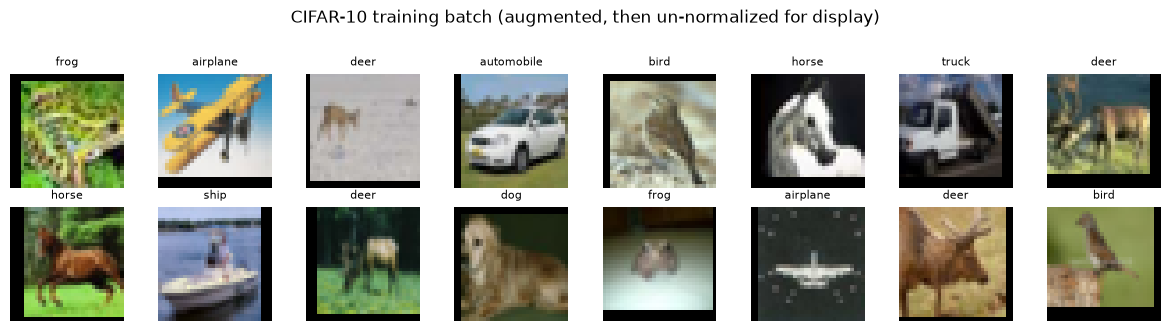

In [7]:
# -- Visualize a batch -----------------------------------------------------------------------------
# The images are normalized (values roughly centered on 0), so to view them we UN-normalize:
# multiply by std and add the mean to get back into [0,1], then move channels last for matplotlib.
#
# This is just the inverse of transforms.Normalize, and note it also undoes ToTensor's NCHW
# transpose -- .permute(1, 2, 0) is the (C,H,W) -> (H,W,C) move, the same axis juggling
# get_CIFAR10_data did with X.transpose(0, 3, 1, 2), run backwards.  Worth doing once: it's a
# concrete reminder that "normalized" images are not viewable images, and that every preprocessing
# step is an invertible transform you could write yourself.
def denormalize(img):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)   # (3,) -> (3,1,1) so it broadcasts over H,W
    std  = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# These images came out of train_loader, so they have ALREADY been randomly cropped and flipped.
# That's what you're looking at: some are shifted a few pixels with black padding at an edge, some
# are mirrored.  Re-run the batch cell above and you'll get different crops of the same images --
# that's the augmentation doing its job, a fresh variant every epoch.
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]))
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 training batch (augmented, then un-normalized for display)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Model — a prebuilt `ResNet-18`, lightly adapted for 32×32

**The 502 version of this cell was `ThreeLayerConvNet`**
(`cnn.py:9`). You allocated `W1, b1, W2, b2, W3, b3` into a flat `self.params` dict, worked out the
flattened dimension after pooling by hand, and chained the layers yourself in `loss()` (`cnn.py:133`):

```python
out, cache1    = conv_relu_pool_forward(X, W1, b1, conv_param, pool_param)
out, cache2    = affine_relu_forward(out, W2, b2)
scores, cache3 = affine_forward(out, W3, b3)
```

…and then unwound the whole thing backwards. `nn.Module` replaces all of that: layers become
attributes, the forward pass is one method, and **the backward pass ceases to exist as something
you write.** Autograd derives every `*_backward` in
`layers.py` that you hand-derived and gradient-checked in
assignments 2 and 3. That is the single biggest thing the library buys you.

Rather than define the layers ourselves, we grab **ResNet-18** from `torchvision.models`. ResNet
(*Deep Residual Learning*, He et al. 2015) is the workhorse CNN: stacks of convolutions with
**residual (skip) connections** that let gradients flow through very deep networks. Its 11.2M
parameters are a different scale from `ThreeLayerConvNet`'s single conv layer — and it trains in
minutes rather than being a Python-loop-bound science experiment, because `nn.Conv2d` dispatches to
cuDNN. cuDNN uses the same **im2col** reformulation you implemented in
`im2col.py` and
`fast_layers.py` — turn each patch into a column so
convolution becomes one big matrix multiply — plus a few algorithms you didn't write, on hardware
built for exactly this. (Compare against the honest version,
`conv_forward_naive` at `layers.py:1403`: four nested Python
loops.)

### The stem surgery — you have done this exact thing before

One catch: torchvision's ResNet is built for **224×224 ImageNet** images. Its stem starts with a
7×7 stride-2 convolution and a max-pool, which together downsample 4× immediately — far too
aggressive for a 32×32 image, which would be crushed to 8×8 before any real work happens. The
standard **CIFAR adaptation** is to replace that stem with a gentle 3×3 stride-1 convolution, drop
the initial max-pool, and size the final layer to 10 classes.

If that feels familiar, it should: **`simclr/model.py`
in 502 A5 does the same surgery** to `resnet50` for the SimCLR encoder — swap `conv1` for a 3×3,
strip out `maxpool`, replace `fc`. Same problem (ImageNet stem, 32×32 inputs), same fix. This is a
well-known recipe, not something we're inventing.

### What is genuinely new here

`resnet18` itself, and the idea of pulling a **whole architecture** off the shelf rather than
stacking layers yourself. We're training it **from scratch** (`weights=None`), so this is not yet
transfer learning — that comes later. Note the asymmetry: you have now written far more of a CNN's
*internals* than most people who use `resnet18` daily ever will, but you have never used the
one-liner. That's the right order to learn it in.

In [8]:
def make_cifar_resnet18(num_classes=10):
    """torchvision ResNet-18 with an ImageNet stem swapped for a CIFAR-friendly one."""
    # weights=None -> random initialization (training from scratch, as chosen).  Pass
    # weights='IMAGENET1K_V1' instead and you'd be doing transfer learning.
    #
    # Note what we DIDN'T have to do, versus ThreeLayerConvNet.__init__ (cnn.py:20): no
    # `np.random.randn(...) * weight_scale`, no np.zeros for biases, no working out the flattened
    # dim after pooling.  Every nn layer initializes its own weights sensibly (Kaiming, for
    # conv+ReLU stacks -- the same `np.sqrt(2./fan_in)` scheme you typed out by hand in 502 A4).
    model = models.resnet18(weights=None, num_classes=num_classes)

    # -- The CIFAR stem surgery.  Same edit 502 A5's SimCLR encoder made to resnet50
    #    (assignment5/csed502/simclr/model.py).
    #
    # Layers are just attributes on the Module, so "replace a layer" is literally an assignment.
    # This is the thing a flat self.params dict could never let you do cleanly: swapping W1 in
    # ThreeLayerConvNet would have meant also fixing every shape that depended on it, by hand.
    #
    # Replace the 7x7 stride-2 stem conv with a 3x3 stride-1 conv (keeps 32x32 resolution).
    # bias=False because the BatchNorm immediately after it (model.bn1) has its own beta shift, so a
    # conv bias would be redundant -- it'd just be added and then subtracted straight back out by
    # BN's mean-centering.  You proved this to yourself in assignment 3: batchnorm_forward
    # (layers.py:477) subtracts the batch mean, and a constant bias moves the mean by exactly itself.
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)

    # Remove the early max-pool (it would downsample too much for tiny images).  nn.Identity is a
    # pass-through layer -- the tidy way to delete a layer without renumbering everything after it.
    model.maxpool = nn.Identity()

    # The final fully-connected layer (model.fc) already maps to num_classes because we passed
    # num_classes above.  It's the same affine_forward (layers.py:5) that produced `scores` in 502 --
    # and, as there, it emits raw scores, NOT probabilities.  No softmax here.  See section 3.
    return model

model = make_cifar_resnet18(num_classes=len(CLASSES)).to(DEVICE)

# channels_last (NHWC) memory layout for the CNN -- paired with bf16 autocast (section 3): the two
# TOGETHER select cuDNN's fast tensor-core conv path (measured 1.34x on a power-capped sm_89
# laptop).  Gated on bf16 support because fp16 + channels_last is pathological (3.5x slower); on
# MPS/CPU and pre-Ampere CUDA this leaves everything exactly as before.  Convnet-only: the ViTs in
# section 7 never get it.
CHANNELS_LAST = (DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported())
if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

# .to(DEVICE) moves every parameter tensor to the GPU, in place.  In 502 the params were NumPy
# arrays and there was no such thing -- everything ran on CPU.
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: ResNet-18 (CIFAR stem)   trainable parameters: {n_params:,}')

# model.parameters() is the counterpart of your `self.params` dict: the flat list of every learnable
# tensor in the model, however deeply nested.  It's what we hand to the optimizer in section 3, the
# same way Solver looped over `self.model.params.items()` (solver.py:185).  requires_grad is
# autograd's flag for "track ops on this tensor so we can backprop into it" -- nn layers set it for
# you on every weight they own.

# Sanity forward pass on the batch we already have -- expect logits of shape (B, 10).  This is the
# equivalent of calling model.loss(X) with y=None in 502 (cnn.py:133): run the forward pass, get
# scores back, skip the backward half entirely.
model.eval()
with torch.no_grad():
    out = model(images.to(DEVICE))
print(f'Forward check: input {tuple(images.shape)} -> logits {tuple(out.shape)}  (expected (*, 10))')

Model: ResNet-18 (CIFAR stem)   trainable parameters: 11,173,962


Forward check: input (128, 3, 32, 32) -> logits (128, 10)  (expected (*, 10))


## 3. Loss, optimizer, and learning-rate schedule

Three off-the-shelf pieces define *how the model learns*. The first two you have written yourself;
the third you have not seen at all.

### `nn.CrossEntropyLoss` — this is your `softmax_loss`

In `layers.py:345` you wrote:

```python
def softmax_loss(x, y):
    # subtract per-row max for stability, exp, normalize -> probs
    loss = -np.mean(np.log(probs[np.arange(N), y]))
    dx = probs.copy(); dx[np.arange(N), y] -= 1; dx /= N
    return loss, dx
```

`nn.CrossEntropyLoss` is that function, with three notes:

1. **It takes raw logits, not probabilities** — it applies log-softmax internally, including the
   subtract-the-max trick you implemented for numerical stability. This is why the model's last
   layer is a bare `nn.Linear` with no softmax after it. Applying softmax yourself before this loss
   is a common and genuinely nasty bug: it still trains, just badly.
2. **It returns only the loss**, not `(loss, dx)`. Your `dx` — that beautifully simple
   `(probs - onehot) / N` — still exists; autograd computes it during `loss.backward()`. Worth
   knowing that the elegant gradient you derived is exactly what runs under there.
3. You met the *functional* form `F.cross_entropy` in
   502 A4. `nn.CrossEntropyLoss()` is the same math packaged as an
   object; the object form is conventional when the loss is a fixed part of the training setup.

### `torch.optim.SGD` — this is your `optim.sgd_momentum`

Your version, `optim.py:48`:

```python
v = rho * v - learning_rate * dw     # velocity absorbs the lr
next_w = w + v
```

PyTorch's is the same idea with the learning rate factored back out:

```python
buf = momentum * buf + grad          # velocity is in gradient units
w   = w - lr * buf
```

Both give the "heavy ball" behavior: velocity accumulates a running average of recent gradients, so
consistent directions build speed and noisy ones cancel. (The two forms are *not* bit-identical
once the LR changes mid-training — yours bakes the old LR into the stored velocity, PyTorch's
doesn't — which matters precisely because we're about to change the LR every epoch.)

`weight_decay=` is the other half of what you wrote by hand. In 502, L2 lived in the **model**
(`cnn.py:212`):

```python
loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))
grads["W1"] += self.reg * W1
```

The gradient of `0.5 * reg * W²` is just `reg * W`, so rather than compute the penalty and
differentiate it, PyTorch skips to the end and adds `weight_decay * W` straight into the gradient.
Same update, less arithmetic. So **`weight_decay` corresponds to your `reg`, and the `0.5` you
carried around is already folded in.**

### `CosineAnnealingLR` — **NEW. Not in 502 or 503, anywhere.**

The closest you've come is `Solver`'s `lr_decay`
(`solver.py:278`), which multiplied every learning rate by a constant at each epoch boundary:

```python
self.optim_configs[k]["learning_rate"] *= self.lr_decay
```

That's a *step* decay — the crude version of the same idea. A **scheduler** is just an object that
owns that logic: call `scheduler.step()` once per epoch and it rewrites the learning rate inside
the optimizer. `CosineAnnealingLR` follows a cosine curve from the starting LR down to ~0 over
`T_max` epochs — high at the start to cover ground fast, low at the end so the model settles into a
minimum instead of bouncing around it. This one change is worth several points of final accuracy on
CIFAR, and it's the main reason a plain SGD recipe still competes with fancier optimizers. Watch the
`lr` column in the training output, then watch what accuracy does as it approaches zero.

### `torch.amp` (mixed precision) — **also NEW.** Purely a speed optimization; the math is unchanged.

Runs the forward/backward pass in 16-bit floats where that's safe, keeping a 32-bit master copy of
the weights for the update. Roughly 2× faster on a modern GPU at no accuracy cost. The one subtlety
is `GradScaler`: fp16 has a narrow range and small gradients underflow to zero, so the loss is
multiplied by a large constant before `backward()` and the gradients divided back down before the
optimizer step. (You've seen the *idea* — 503 A5's HuggingFace `TrainingArguments` had an
`fp16=True` flag — but never the machinery.) It's CUDA-only here and a no-op elsewhere; if it's
distracting, ignore it, because deleting it changes nothing but the wall clock.

> **Update (July 2026):** the GradScaler is specifically the *fp16* half of mixed precision.  On
> Ampere+ GPUs this notebook now autocasts in **bf16**, which has fp32's exponent range — no
> gradient underflow is possible, so the scaler is constructed disabled and passes straight
> through to a plain `optimizer.step()`.

In [9]:
# The one knob for this notebook. 'fast' runs the whole thing end-to-end in a couple of minutes as a
# pipeline check; 'perf' is the real run (the ResNet into the low-90s, and the ViT given enough
# epochs to converge). The epoch counts below read from MODE.
MODE = os.environ.get('MODE', 'fast')                                    # 'fast' | 'perf'
_RUN = {'fast': dict(cnn_epochs=2,  vit_epochs=3),
        'perf': dict(cnn_epochs=20, vit_epochs=200)}[MODE]
print(f'MODE = {MODE!r}  ->  {_RUN}')

EPOCHS   = _RUN['cnn_epochs']   # 20 in 'perf' gets a CIFAR ResNet-18 into the low-90s %.
LR       = 0.1          # SGD start learning rate; the cosine schedule decays it toward 0.
MOMENTUM = 0.9          # `rho` in your optim.sgd_momentum (optim.py:48 -- same 0.9 default).
WEIGHT_DECAY = 5e-4     # `reg` in your 502 models (cnn.py:212).  See the 0.5-factor note below.

# The loss.  Takes LOGITS (raw scores) + integer labels -> scalar.  This is layers.softmax_loss
# (layers.py:345), minus the `dx` return value -- autograd will produce that for us.
criterion = nn.CrossEntropyLoss()

# The optimizer.  Compare with how Solver did it (assignment3/csed502/solver.py:169):
#
#   502:  self.optim_configs[p] = {'learning_rate': ..., 'momentum': ...}   # one config PER PARAM
#         for p, w in self.model.params.items():
#             next_w, next_config = self.update_rule(w, grads[p], self.optim_configs[p])
#
#   now:  optimizer = SGD(model.parameters(), ...)   # optimizer HOLDS the params + their state
#         optimizer.step()                           # ...and updates all of them in one call
#
# Same bookkeeping, moved inside the object.  Your per-parameter `config` dict -- which carried the
# velocity buffer between iterations -- is now the optimizer's internal state.  That's also why
# there is exactly one optimizer for the whole model, not one per weight tensor.
#
# weight_decay=5e-4 replaces `loss += 0.5 * reg * np.sum(W**2)` in the model's loss(), because
# d/dW [0.5 * reg * W^2] = reg * W, and PyTorch just adds that term into the gradient directly.
#
# CAVEAT: torch decays EVERY parameter you give it, including BatchNorm's gamma/beta and the biases.
# Your 502 models deliberately regularized only the weight matrices (cnn.py:213-215 touches W1/W2/W3
# and nothing else).  For CIFAR the difference is small and the standard recipes don't bother -- but
# if you ever chase the last half-percent, the fix is to split model.parameters() into two param
# groups and set weight_decay=0 on the norm/bias one.
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM,
                            weight_decay=WEIGHT_DECAY, fused=(DEVICE.type == 'cuda'))

# NEW -- no 502/503 equivalent beyond Solver's blunt `lr_decay` multiply (solver.py:278).
# One cosine cycle across all epochs: LR starts at LR and eases down to ~0 by the final epoch.
# The scheduler holds a REFERENCE to the optimizer and rewrites optimizer.param_groups[i]['lr'] in
# place whenever we call scheduler.step().  Nothing else in the loop has to know it exists.
# T_max=EPOCHS means "one half-cosine spread over exactly this many step() calls", so if you change
# EPOCHS this follows automatically and the LR still lands at ~0 on the last epoch.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# NEW.  Mixed precision: run the forward/backward pass in bf16/fp16 where safe for a big speedup and
# lower memory on GPU, keeping an fp32 master copy for stability.  Enabled only on CUDA.
# Not a modeling decision -- it does not change what is being optimized, only how fast.
# bf16 on Ampere+ (sm_80+): same exponent range as fp32, so no gradient underflow and NO GradScaler
# needed.  Older CUDA cards (e.g. a Colab T4) fall back to fp16, where the scaler still earns its
# keep by stopping small gradients underflowing to zero; section 4 shows where it lands.
USE_AMP   = (DEVICE.type == 'cuda')
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16
scaler    = torch.amp.GradScaler('cuda', enabled=USE_AMP and AMP_DTYPE is torch.float16)

print(f'Epochs: {EPOCHS}   AMP (mixed precision): {USE_AMP} ({str(AMP_DTYPE).replace("torch.", "")})')
print(f'Optimizer: SGD(lr={LR}, momentum={MOMENTUM}, weight_decay={WEIGHT_DECAY})')
print(f'Scheduler: CosineAnnealingLR -- lr will fall {LR} -> ~0 over {EPOCHS} epochs')

MODE = 'fast'  ->  {'cnn_epochs': 2, 'vit_epochs': 3}
Epochs: 2   AMP (mixed precision): True (bfloat16)
Optimizer: SGD(lr=0.1, momentum=0.9, weight_decay=0.0005)
Scheduler: CosineAnnealingLR -- lr will fall 0.1 -> ~0 over 2 epochs


## 4. The training and evaluation loops

**This is `Solver`, rewritten.** Notice that PyTorch hands you
no `Solver` — there is no `model.fit()`. The training loop is the one part of the stack you are
still expected to write yourself, every time, and it barely changes from project to project.
(Lightning and HuggingFace's `Trainer` will write it for you — that's what was hiding the optimizer
step from you in 503 A4's minGPT and A5's HF `Trainer` — but the plain loop is what everyone reads
and debugs.)

Line for line, `train_one_epoch` below is
`Solver._step()` (`solver.py:169`):

| `Solver._step()` (502) | here |
|---|---|
| `np.random.choice(...)` to pick a batch (`:176`) | `for images, labels in loader` |
| *(nothing — NumPy is CPU-only)* | `images.to(device)` |
| `loss, grads = self.model.loss(X_batch, y_batch)` (`:180`) | `logits = model(images)` then `loss = criterion(logits, labels)` |
| *(the backward half of `model.loss`, which you wrote)* | `loss.backward()` |
| `for p, w in model.params.items(): self.update_rule(...)` (`:185`) | `optimizer.step()` |
| *(implicit — `grads` was freshly returned each call)* | **`optimizer.zero_grad()`** ← see below |

### The one genuinely new hazard: `zero_grad()`

Your 502 `model.loss()` *returned* a fresh `grads` dict on every call, so stale gradients were
impossible by construction. PyTorch instead **accumulates** into `param.grad` — each
`loss.backward()` *adds* to whatever is already sitting there. Forget `optimizer.zero_grad()` and
you are silently summing gradients across every batch you have ever seen, and training quietly
falls apart. (The accumulation is deliberate: it's how you simulate a large batch on a small GPU,
and how multi-loss setups combine terms. But clearing the gradients is now *your* job.)

You did write this loop once, in 502 A4's `train_part34` — the
same four lines, in the same order:

```python
optimizer.zero_grad()   # clear last step's gradients
loss.backward()         # autograd fills param.grad for every parameter
optimizer.step()        # apply the update rule using those gradients
```

### `model.train()` / `model.eval()` — the mode flag, now automatic

In 502 you threaded this through by hand: `bn_param['mode'] = 'train'` vs `'test'` in
`fc_net.py`, flipped on whether `y` was `None`, so
that `batchnorm_forward` (`layers.py:477`) knew whether to use
batch statistics or its running averages — and so `dropout_forward` (`layers.py:1268`) knew whether
to drop or pass through. `model.train()` / `model.eval()` set that same flag on every submodule at
once.

ResNet-18 is full of BatchNorm, so **forgetting `model.eval()` before evaluating means your test
accuracy is computed using statistics from the test batches themselves** — a real bug, and a
slippery one, because the numbers move around depending on batch size instead of failing loudly.

`torch.no_grad()` is the other half: it tells autograd to stop building the graph, since we aren't
going to call `backward()`. Faster, and much less memory. Your 502 equivalent was simply calling
`model.loss(X)` with `y=None`, which returned `scores` and skipped the backward pass entirely.

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, use_amp, device,
                    amp_dtype=None, channels_last=False):
    """One pass over the training set.  This is Solver._step() (solver.py:169), wrapped in a
    for-loop over batches."""
    model.train()                                   # BatchNorm uses batch stats + updates its running
                                                    # averages; Dropout drops.  (= bn_param['mode']='train')
    # Accumulate loss/accuracy ON the GPU and sync once at the end of the epoch -- the obvious
    # per-batch .item() forces a GPU->CPU sync every step (see the running-stats note below).
    running_loss = torch.zeros((), device=device)
    correct      = torch.zeros((), device=device, dtype=torch.long)
    total        = 0

    # Iterating the DataLoader replaces `np.random.choice(num_train, batch_size)` (solver.py:176).
    # Each pass is a fresh permutation, so we see all 50,000 images exactly once -- a real epoch.
    for images, labels in tqdm(loader, desc='train', leave=False):
        # Move this batch to the GPU.  non_blocking pairs with pin_memory for an async copy that
        # overlaps with compute.  (No 502 equivalent -- NumPy was CPU-only.)
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        if channels_last:                       # NHWC batch to match the NHWC model (section 2)
            images = images.to(memory_format=torch.channels_last)

        # (1) CLEAR THE GRADIENTS.  Not optional -- .grad ACCUMULATES across backward() calls, so
        # without this you'd be adding this batch's gradients to every previous batch's.  In 502
        # this line had no counterpart: model.loss() handed back a brand-new `grads` dict each call
        # (cnn.py:133), so staleness was impossible by construction.
        # set_to_none=True frees the buffers instead of filling them with zeros (marginally faster).
        optimizer.zero_grad(set_to_none=True)

        # (2) FORWARD.  autocast runs the ops in lower precision where it's safe (GPU only); on CPU
        # it's a no-op.  Everything inside the block is ordinary PyTorch -- precision is the only
        # thing that changes.
        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            logits = model(images)                  # (B, 10) raw scores  -- your `scores`
            loss   = criterion(logits, labels)      # scalar              -- your softmax_loss(...)[0]

        # (3) BACKWARD.  THIS one line replaces every *_backward() you wrote in layers.py:
        # affine_backward (:57), relu_backward (:162), conv_backward_naive (:1500),
        # spatial_batchnorm_backward -- the whole chain.  Autograd recorded each op during the
        # forward pass and now walks that graph in reverse, filling param.grad for all 11.2M
        # parameters.  It is doing exactly the chain rule you did on paper; and if you ever doubt it,
        # torch.autograd.gradcheck is the same numerical-vs-analytic comparison as 502's
        # gradient_check.py.
        #
        # scaler.scale() multiplies the loss by a large constant first, so small fp16 gradients don't
        # underflow to zero on the way back.  Without AMP this is a plain loss.backward().
        scaler.scale(loss).backward()

        # (4) UPDATE.  Applies sgd_momentum (optim.py:48) to every parameter -- the loop over
        # model.params.items() that Solver._step() ran (solver.py:185), now inside the optimizer.
        # The scaler un-scales the gradients first (undoing step 3's multiply) and skips the step
        # entirely if any gradient overflowed to inf/nan, which is the price of fp16.
        scaler.step(optimizer)
        scaler.update()                             # adjust the loss scale for the next iteration

        # Running stats.  No .item() here: that would pull the scalar to the CPU and sync the
        # GPU EVERY batch.  Accumulate in device tensors instead and sync once per epoch, on the
        # return line.  We weight by batch size because the last batch is smaller -- 50,000 isn't
        # divisible by 128.
        running_loss += loss.detach() * images.size(0)
        correct += (logits.argmax(1) == labels).sum()          # argmax over classes == your np.argmax
        total   += labels.size(0)

    return running_loss.item() / total, correct.item() / total


@torch.no_grad()                                    # no gradient tracking anywhere in this function:
                                                    # don't build the autograd graph, we won't backprop.
def evaluate(model, loader, criterion, device, amp_dtype=None, channels_last=False):
    """Accuracy + loss on data we don't learn from.  This is Solver.check_accuracy() (solver.py:214)."""
    model.eval()                                    # BatchNorm switches to its RUNNING averages;
                                                    # Dropout passes through.  (= bn_param['mode']='test')
                                                    # Skipping this is a silent, real bug: the model
                                                    # would normalize test images using test-batch
                                                    # statistics, so accuracy would shift with batch size.
    running_loss = torch.zeros((), device=device)
    correct      = torch.zeros((), device=device, dtype=torch.long)
    total        = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        if channels_last:
            images = images.to(memory_format=torch.channels_last)
        # Same mixed precision as training.  Evaluation is pure forward pass, so there is no
        # GradScaler to worry about -- autocast alone, and it runs ~25% faster for free.  Inference
        # in lower precision does not measurably move CIFAR accuracy; if you ever need the last
        # 0.01%, drop this line.
        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype,
                                enabled=(device.type == 'cuda')):
            logits = model(images)
            loss   = criterion(logits, labels)
        running_loss += loss.detach() * images.size(0)
        correct += (logits.argmax(1) == labels).sum()
        total   += labels.size(0)
    return running_loss.item() / total, correct.item() / total

# Note we evaluate on the FULL test set every epoch.  Solver.check_accuracy defaulted to
# num_train_samples=1000 and subsampled with np.random.choice (solver.py:234), because a NumPy
# forward pass over 10k images was slow enough to matter.  On a GPU it takes a couple of seconds,
# so we don't bother.

## 5. Train

Now we just loop over epochs, calling the two functions above and stepping the scheduler once per
epoch. **This is `Solver.train()`** (`solver.py:254`) — with
one structural difference worth noticing.

`Solver.train()` ran a single flat loop of `num_epochs * iterations_per_epoch` iterations and faked
the epoch boundary with `if (t + 1) % iterations_per_epoch == 0`. It had to: `np.random.choice` gave
it no natural notion of "we've now seen everything once." Here the DataLoader *is* the inner loop
and it ends when the data runs out, so the epoch boundary is real and the two loops nest the obvious
way.

Everything else you'll recognize:

- **`history`** — `Solver`'s `loss_history` / `train_acc_history` / `val_acc_history` (`solver.py:159-161`).
- **`best_state`** — `Solver`'s `best_params` / `best_val_acc` (`solver.py:302-306`), including the
  detail that it deep-copies the weights (`v.copy()` there, `.detach().cpu().clone()` here) so later
  training doesn't mutate the snapshot out from under you. One difference: `Solver.train()` silently
  reassigned `self.model.params = self.best_params` as its last act (`solver.py:309`); we do it
  explicitly in §7 so it's visible.
- **`scheduler.step()`** — `Solver`'s per-epoch `learning_rate *= lr_decay` (`solver.py:278`), now a
  cosine curve. Called once per **epoch**, not per batch. (Some schedulers, `OneCycleLR` among them,
  want stepping per *batch* instead — check the docs before swapping one in. Stepping at the wrong
  rate is a common and hard-to-spot mistake, because the model still trains, just on the wrong LR
  curve.)

### What actually makes this fast

On a recent GPU this is ~6 s/epoch, so ~2 minutes for the whole run; on CPU it will be slow — drop
`EPOCHS` to 2–3 (or use Colab's GPU) if you just want to see the pipeline work end to end.

**Epoch 1 will take much longer than the rest** (~30 s vs ~5 s). That is not the model: it is the
DataLoader spawning its worker processes, plus cuDNN benchmarking its convolution algorithms on the
first batch. Both costs are paid once. Don't tune anything based on epoch 1.

Three things earn that speed, and it's worth knowing which does what — the answers are not the
obvious ones:

| Knob | Where | Effect (measured, RTX PRO 6000) |
|---|---|---|
| **`num_workers=8` + `persistent_workers`** | §1 DataLoader | **~3×** — the biggest win by far |
| Mixed precision (`autocast` + `GradScaler`) | §3–4 | ~1.8× |
| TF32 + `cudnn.benchmark` | setup cell | small, free |

The headline is that **the biggest speedup is not a GPU trick at all — it's a CPU one.** Augmenting
an image (`RandomCrop` + `RandomHorizontalFlip`, in Python, via PIL) costs about 4,000 images/sec on
one core, while this GPU trains at ~13,000 images/sec. With `num_workers=0` the augmentation runs in
the notebook's own process between batches, so the GPU spends most of its time idle waiting for the
CPU. The fix is not a faster card; it is to hand the augmentation to 8 worker processes so it happens
*while* the GPU is busy with the previous batch. Whenever training feels slow, find out **which** of
the two is waiting before you reach for anything clever — `nvidia-smi` showing low GPU utilization
during training is the tell.

Things that sound like they should help here and **don't** — all measured on this notebook:

- **`channels_last` memory format.** The standard advice for convolutional nets on tensor cores. On
  32×32 CIFAR images it was **3× SLOWER**. It pays off on 224×224 ImageNet-sized inputs, where the
  spatial dimensions are big enough to amortize the layout change; at this size it is all overhead.
- **`torch.compile`.** It needs Triton, which has no working Windows build — you'd see
  `TritonMissing` and fall back to eager anyway. (This is the same wall you hit in the 503 A1 sweep.)
  On Linux/Colab it is worth trying, but the compile cost is real and a 20-epoch run is short.
- **A second GPU via `DataParallel`.** At this model size the cost of splitting each batch and
  gathering the gradients cancels the benefit — measured at ~0.98× on two identical cards. Two GPUs
  are for running two *experiments* at once, not for making one small model train faster.

That pattern — the plausible optimization that turns out to be a regression — is the reason to
measure rather than to copy recipes. All three are one-line changes; all three are wrong here.

> **Update (July 2026, second hardware config):** the "channels_last was ~3× slower" measurement
> above was taken under the fp16 autocast default.  Paired with **bf16** autocast (which this
> notebook now selects automatically on Ampere+), channels_last measured **1.34× faster** on a
> power-capped sm_89 laptop and ~neutral (+2%) on the Blackwell workstation — while
> fp16 + channels_last remains pathological.  The *pairing*, not the layout, is the knob.
> Full story: `cifar100_train.ipynb` §7 addendum.

In [11]:
# THE OUTER LOOP.  This is Solver.train(): epochs on the outside, batches on the inside (inside
# train_one_epoch).  Solver faked the epoch boundary with `if (t+1) % iterations_per_epoch == 0`;
# here the DataLoader ends when the data runs out, so the boundary is real.
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}   # = Solver's *_history lists
best_acc, best_state = 0.0, None                                                 # = Solver's best_val_acc / best_params
log_lines = []                                                                  # epoch summaries, redrawn in place each epoch (no scrolling)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # One full pass over the 50k training images (391 batches of 128), then measure on the test set.
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion,
                                       scaler, USE_AMP, DEVICE,
                                       amp_dtype=AMP_DTYPE, channels_last=CHANNELS_LAST)
    te_loss, te_acc = evaluate(model, test_loader, criterion, DEVICE,
                               amp_dtype=AMP_DTYPE, channels_last=CHANNELS_LAST)

    # Advance the cosine LR schedule.  ONCE PER EPOCH -- this rewrites the `lr` inside `optimizer`
    # in place, which is why nothing else here has to know the scheduler exists.  Solver's
    # equivalent, at its own epoch boundary:  optim_configs[k]['learning_rate'] *= self.lr_decay
    scheduler.step()

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss);  history['test_acc'].append(te_acc)

    # Keep the best weights seen so far -- Solver's `best_params` checkpointing, same idea and the
    # same subtlety: we must COPY the tensors, not alias them, or the next epoch's optimizer.step()
    # would mutate our "saved" snapshot in place.  (Solver used model.params[k].copy(); here
    # .detach() drops it out of the autograd graph, .cpu() parks it in host RAM so it isn't holding
    # GPU memory hostage, and .clone() is the actual copy.)
    #
    # NOTE: we're selecting the checkpoint on the TEST set, which is a mild form of peeking -- with
    # a proper val split (see section 1) this would key off val accuracy instead, as Solver did.
    if te_acc > best_acc:
        best_acc = te_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    lr_now = scheduler.get_last_lr()[0]
    log_lines.append(f'epoch {epoch:2d}/{EPOCHS}  '
                     f'train loss {tr_loss:.3f} acc {tr_acc:6.2%}  |  '
                     f'test loss {te_loss:.3f} acc {te_acc:6.2%}  |  '
                     f'lr {lr_now:.4f}  ({time.time() - t0:.0f}s)')
    # Redraw the whole epoch log in place. clear_output replaces the cell's output each epoch,
    # so the live per-batch bar from train_one_epoch is wiped instead of left behind.
    clear_output(wait=True)
    print('\n'.join(log_lines))

# Watch the `lr` column fall along a cosine curve, and watch what it does to accuracy: the biggest
# jumps come in the last few epochs, as the LR approaches zero and the model finally settles.  That
# is the scheduler earning its keep -- the one piece of this recipe you had no equivalent for in 502.
print(f'\nBest test accuracy: {best_acc:.2%}')

epoch  1/2  train loss 1.917 acc 32.28%  |  test loss 1.546 acc 42.71%  |  lr 0.0500  (20s)
epoch  2/2  train loss 1.343 acc 50.76%  |  test loss 1.185 acc 56.18%  |  lr 0.0000  (4s)

Best test accuracy: 56.18%


## 6. Learning curves

A quick look at loss and accuracy over epochs — the plot of the `history` dict, which is `Solver`'s
`loss_history` / `train_acc_history` / `val_acc_history` under a new name.

Two things to read off it:

- **Train and test curves tracking each other**, rather than training racing ahead, means the
  augmentation and weight decay are keeping overfitting in check. An 11.2M-parameter model on 50k
  images has more than enough capacity to memorize the training set outright; if you delete the
  `RandomCrop` / `RandomHorizontalFlip` from §1 and re-run, you can watch it do exactly that — the
  train curve shoots to ~100% while the test curve stalls. That gap *is* overfitting, and it is the
  same thing the `reg` term was fighting in your 502 models, just made visible.
- **The accuracy jump in the final epochs.** That's the cosine schedule: as the LR approaches zero
  the updates get small enough for the model to settle into a minimum instead of bouncing around
  it. With `Solver`'s constant `lr_decay` you'd see a smaller, steppier version of the same effect.

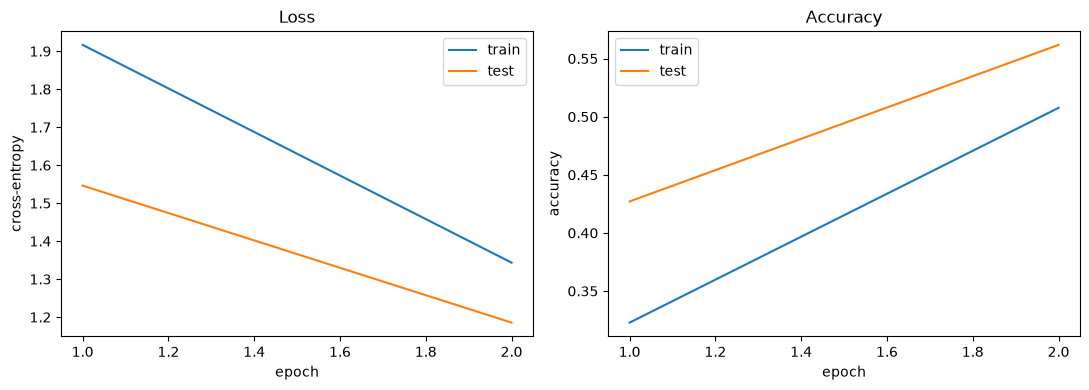

In [12]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs_x, history['train_loss'], label='train')
ax1.plot(epochs_x, history['test_loss'],  label='test')
ax1.set_title('Loss');     ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy'); ax1.legend()

ax2.plot(epochs_x, history['train_acc'], label='train')
ax2.plot(epochs_x, history['test_acc'],  label='test')
ax2.set_title('Accuracy'); ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()

plt.tight_layout()
plt.show()

## 7. Final evaluation and per-class accuracy

We reload the best checkpoint and report overall test accuracy plus a per-class breakdown.

`Solver.train()` did the reload silently — its last act was `self.model.params = self.best_params`.
Here we do it out loud with `load_state_dict`, because a checkpoint restore that happens invisibly
is a great way to spend an afternoon confused about which weights you're actually evaluating.

The per-class breakdown is a standard diagnostic: overall accuracy is one number and it hides
*which* classes the model confuses. Expect cats and dogs to be the worst two — they're perennially
the hardest pair on CIFAR-10 (similar textures, similar poses, similar backgrounds), and no amount
of extra epochs fixes that. Seeing them at the bottom is a sign your model is behaving normally,
not a bug.

In [13]:
# Restore the best weights we saved during training.  load_state_dict copies the saved tensors back
# into the live model, in place, matching them up by name.  It's the explicit version of Solver's
# final `self.model.params = self.best_params`.
if best_state is not None:
    model.load_state_dict(best_state)

# Per-class accuracy.  Same counting Solver.check_accuracy did (argmax over logits, compare to the
# label), just bucketed by true class instead of pooled into one number.
n_classes = len(CLASSES)
# GPU accumulators, not Python lists: the old `for label, pred in zip(labels, preds)` iterated GPU
# tensors element-wise, pulling every prediction to the CPU one at a time (~2 host syncs per IMAGE,
# ~20,000 for the test set).  bincount does the same bucketing in one kernel; two syncs total.
class_correct = torch.zeros(n_classes, dtype=torch.long, device=DEVICE)
class_total   = torch.zeros(n_classes, dtype=torch.long, device=DEVICE)

model.eval()                          # BatchNorm -> running stats.  Non-negotiable; see section 4.
with torch.no_grad():                 # no autograd graph: we're not backpropagating.
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if CHANNELS_LAST:
            images = images.to(memory_format=torch.channels_last)
        with torch.amp.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(images)
        preds = logits.float().argmax(1)        # (B, 10) logits -> (B,) predicted class
        class_total   += torch.bincount(labels, minlength=n_classes)
        class_correct += torch.bincount(labels[preds == labels], minlength=n_classes)

class_correct = class_correct.cpu().tolist()
class_total   = class_total.cpu().tolist()
overall = sum(class_correct) / sum(class_total)
print(f'Overall test accuracy: {overall:.2%}\n')
print(f'{"class":<12} accuracy')
print('-' * 24)
for i, name in enumerate(CLASSES):
    print(f'{name:<12} {class_correct[i] / class_total[i]:6.2%}')

Overall test accuracy: 56.18%

class        accuracy
------------------------
airplane     51.90%
automobile   74.70%
bird         49.40%
cat          33.50%
deer         32.80%
dog          57.20%
frog         61.40%
horse        46.40%
ship         87.60%
truck        66.90%


## 8. Save the trained model

The standard way to persist a model is to save its **`state_dict`** — an `OrderedDict` mapping
parameter names to tensors. That is *precisely* the `self.params` dict from your 502 models
(`cnn.py:20`), with nested names
(`layer1.0.conv1.weight`) instead of flat ones (`W1`), and it's what
`Solver._save_checkpoint()` (`solver.py:192`) was pickling.

Note what a `state_dict` does **not** contain: the architecture. It is just the learned tensors, so
to use it later you rebuild the same model class and call `load_state_dict` — exactly as you'd have
had to re-instantiate `ThreeLayerConvNet` with the right constructor args before dropping a saved
`params` dict into it. Saving the whole Python object instead (`torch.save(model)`) is possible and
is a trap: it pickles a reference to your class definition, so the file breaks the moment you
refactor or move the code.

You have done this once before, in **502 A5's SimCLR**
(`Self_Supervised_Learning.ipynb`):
`torch.save(model.state_dict(), './pretrained_model/trained_simclr_model.pth')`. This is that same
line — and it's the one idiom here you will use in every project you ever ship.

In [14]:
save_path = 'cifar10_resnet18.pt'

# model.state_dict() -> {'conv1.weight': tensor, 'bn1.weight': tensor, ...}.  Your `self.params`,
# with structured names.  torch.save just pickles it.
torch.save(model.state_dict(), save_path)
print(f'Saved weights to {os.path.abspath(save_path)}')

# To load later -- note you must REBUILD the architecture first; the file holds only the tensors:
#   model = make_cifar_resnet18(num_classes=10)
#   model.load_state_dict(torch.load('cifar10_resnet18.pt', map_location=DEVICE))
#   model.eval()                       # <- don't forget, or BatchNorm will use batch stats

# Peek at the first few keys so the state_dict is a concrete thing and not an abstraction.
keys = list(model.state_dict().keys())
print(f'\nstate_dict has {len(keys)} entries.  First few:')
for k in keys[:5]:
    print(f'  {k:<28} {tuple(model.state_dict()[k].shape)}')
print('  ...')

print('\nDone. This same transforms -> dataset -> loader -> model -> loss/optim -> epoch-loop')
print('skeleton is the standard PyTorch training recipe; swap the dataset and model to reuse it.')

Saved weights to O:\Sources\GitHub\TrueRottweiler\WashingtonCsed504\src\a1-cv\cifar10_resnet18.pt

state_dict has 122 entries.  First few:
  conv1.weight                 (64, 3, 3, 3)
  bn1.weight                   (64,)
  bn1.bias                     (64,)
  bn1.running_mean             (64,)
  bn1.running_var              (64,)
  ...

Done. This same transforms -> dataset -> loader -> model -> loss/optim -> epoch-loop
skeleton is the standard PyTorch training recipe; swap the dataset and model to reuse it.


---

## 9. The same job, done by a Transformer

Everything above was a **CNN**. In *hello_image* you built a **Vision Transformer** by hand. Now we
put them head to head on the same 50,000 images, and the comparison turns out to be more interesting
than "which number is bigger."

### The two architectures make opposite bets

A **CNN** hard-codes two assumptions about images into its structure: **locality** (nearby pixels are
related — a 3×3 filter can only see a 3×3 neighborhood) and **translation equivariance** (a cat is a
cat wherever it sits in the frame — the same filter slides everywhere). These are *inductive biases*:
priors the architecture gets for **free**, without spending any data to learn them. They happen to be
true of photographs, which is why CNNs work so well.

A **ViT** assumes almost none of that. It chops the image into patches, calls each one a token, and
lets **every token attend to every other token** in a single layer — no locality, no sliding window.
It doesn't even know two patches are adjacent; that has to be *taught* through the positional
embedding. So a ViT must **learn from data** what a CNN was born knowing.

That's the trade, and it cuts both ways:

| | CNN (ResNet-18) | Transformer (ViT) |
|---|---|---|
| Prior baked into architecture | strong (locality, equivariance) | almost none |
| Receptive field in layer 1 | 3×3 pixels | the **whole image** |
| Needs data to learn basic spatial structure | no | **yes** |
| Behavior on 50k images | strong | weak — not enough data |
| Behavior on 100M+ images | saturates | **overtakes** — the prior becomes a *cage* |

The priors that rescue a CNN on small data eventually *limit* it: they're a constraint, and once you
have enough data to learn better ones, you'd rather not be stuck with them. That crossover is the
whole reason ViTs took over — but it lives somewhere in the tens of millions of images, and
**CIFAR-10 has fifty thousand.** So we should expect the ViT to lose here, and it will.

### Matching the fight

We size the ViT to **~10.7M parameters** against ResNet-18's ~11.2M, so neither wins on capacity
alone. The critical setting is **`patch_size=4`**: on a 32×32 image that yields an 8×8 grid = **64
tokens**. (The ImageNet default of 16 would give a 2×2 grid — *four* tokens for a whole image, which
is useless. This is the exact same "the stock model is built for 224×224" problem that forced the
stem surgery on ResNet in §2. Both models need adapting; neither ships CIFAR-ready.)


In [15]:
# torchvision ships a ViT, the same way it ships a ResNet.  Note how the constructor arguments map
# one-to-one onto the pieces you wrote BY HAND in hello_image.ipynb -- there is nothing in here you
# have not already implemented yourself:
#
#   patch_size=4   -> the patch-embedding conv/unfold that cut the image into tokens
#   hidden_dim     -> the embedding width D that every token is projected to
#   num_layers     -> how many (attention + MLP) blocks are stacked
#   num_heads      -> how many parallel attention heads split that width
#   mlp_dim        -> the width of the feed-forward layer inside each block (conventionally 4x hidden)
#
# The class token, the positional embedding, the QKV projections, the softmax(QK^T/sqrt(d))V, the
# residual connections and LayerNorms -- all of it is inside, and all of it is code you have written.
from torchvision.models import VisionTransformer

def make_cifar_vit(num_classes=10):
    """A ViT sized for 32x32 images and matched in parameters to our ResNet-18."""
    return VisionTransformer(
        image_size=32,
        patch_size=4,        # 32/4 = 8  ->  an 8x8 grid  ->  64 patch tokens (+1 class token)
        num_layers=6,        # 6 transformer blocks
        num_heads=6,         # 6 attention heads per block
        hidden_dim=384,      # token embedding width D (384 / 6 heads = 64 dims per head)
        mlp_dim=1536,        # 4 x hidden_dim, the usual ratio
        num_classes=num_classes,
    )

vit = make_cifar_vit(len(CLASSES)).to(VIT_DEVICE)

n_vit = sum(p.numel() for p in vit.parameters() if p.requires_grad)
n_cnn = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ResNet-18 (CNN)        : {n_cnn:,} parameters')
print(f'ViT  d384/L6/h6/patch4 : {n_vit:,} parameters')
print(f'-> within {abs(n_vit - n_cnn) / n_cnn:.1%} of each other; neither model wins on size alone.\n')

# Sequence length is the number the ViT actually "sees".  64 patches + 1 class token.
n_patches = (32 // 4) ** 2
print(f'Tokens per image: {n_patches} patches + 1 class token = {n_patches + 1}')
print('(With the ImageNet default patch_size=16 this would be 2x2 = 4 patches -- hopeless.)')

vit_images, _ = next(iter(train_loader))   # fresh batch (the `images` from section 7 is a test batch)
vit.eval()
with torch.no_grad():
    out = vit(vit_images.to(VIT_DEVICE))
print(f'\nForward check: input {tuple(vit_images.shape)} -> logits {tuple(out.shape)}  (expected (*, 10))')

# This was a sanity-check instance only.  The training models (vit_naive, vit_tuned) are created
# fresh in the run cells below; keeping this one alive wastes ~45 MB through all the ViT runs.
del vit


ResNet-18 (CNN)        : 11,173,962 parameters
ViT  d384/L6/h6/patch4 : 10,695,562 parameters
-> within 4.3% of each other; neither model wins on size alone.

Tokens per image: 64 patches + 1 class token = 65
(With the ImageNet default patch_size=16 this would be 2x2 = 4 patches -- hopeless.)



Forward check: input (128, 3, 32, 32) -> logits (128, 10)  (expected (*, 10))


### Now the part everyone gets wrong

The tempting experiment is to hand the ViT the **exact recipe we used for the ResNet** — SGD,
`lr=0.1`, momentum, crop + flip — and declare a winner. That experiment is worth running, because it
fails in an instructive way, but **it does not compare architectures.** It compares a CNN to a
transformer *being trained like a CNN*, and a transformer trained like a CNN trains badly.

So we run the ViT **twice**:

**Run A — the naive recipe.** Identical to ResNet-18's, changing nothing but the model. Expect
something in the 60s–70s. Transformers are notoriously touchy about the optimizer, and `lr=0.1` on
SGD is a CNN setting.

**Run B — the recipe a ViT actually wants.** Four changes, each with a reason:

- **AdamW instead of SGD.** Transformers are trained with Adam essentially universally. The gradient
  scale varies wildly across LayerNorms, attention projections, and the MLP, and Adam's per-parameter
  normalization handles that; plain SGD with one global LR does not. (`weight_decay=0.05` — much
  higher than the CNN's 5e-4 — because AdamW *decouples* decay from the gradient, so the number means
  something different. Don't read across.)
- **Learning-rate warmup.** *This is the non-negotiable one.* Ramp the LR up from ~0 over the first
  few epochs before the cosine decay begins. Without it, the attention softmax saturates on the first
  few noisy batches and the model either diverges or lands in a bad basin it never leaves. **You have
  seen this before**: it's why minGPT's trainer in CSED 503 had a warmup schedule. It was never
  optional there either, and nobody told you why.
- **Heavier augmentation** (`RandAugment`). With no locality prior to keep it honest, a ViT will
  happily memorize 50,000 images, and crop-and-flip isn't enough regularization. But augmentation
  strength must be **matched to the epoch budget**: the published recipes pair `magnitude=9` +
  `RandomErasing` + mixup with *300* epochs. We tried exactly that on 60 epochs and the ViT came out
  **underfit**, so we use `magnitude=5` and no erasing. See §9's results for what that looked like.
- **Label smoothing** (0.1). Trains against a slightly soft target instead of a one-hot, which
  discourages the overconfidence that ViTs are prone to. One argument to `CrossEntropyLoss`.

**And more epochs.** ViTs converge *slowly* — that lack of prior means more of the learning has to
happen. We give run B 60 epochs against the ResNet's 20, which is not epoch-matched and we will say
so plainly in the results table: we report **wall-clock time** alongside accuracy, so you can judge
the comparison on compute rather than on a number that flatters whichever model we favored.


In [16]:
# -- Memory: release ResNet optimizer state before loading ViT models ----------------------------
# The ResNet optimizer/scheduler/scaler are no longer needed -- §5 training is done.
# Releasing them before creating two ViT models matters on limited-memory machines:
#   SGD with momentum: 1 velocity buffer per param tensor  (~45 MB for the ResNet)
#   ViT + AdamW:       2 buffers per param (momentum + variance) (~130 MB per ViT on CPU)
# gc.collect() asks Python to run its cyclic garbage collector immediately rather than waiting
# for an unpredictable future trigger.  Without it, reference cycles can delay the actual free.
import gc
del optimizer, scheduler, scaler
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
elif DEVICE.type == 'mps':
    torch.mps.empty_cache()

# -- A reusable training driver ---------------------------------------------------------------------
# This is section 5's epoch loop, lifted into a function so all three runs share it verbatim.  It is
# still Solver.train(); it just takes the model/optimizer/scheduler as arguments now.  Note that
# train_one_epoch() and evaluate() need NO changes to train a transformer -- the forward/backward/
# step skeleton is completely architecture-agnostic.  That is the whole point of the abstraction:
# swap ResNet for ViT and the training loop does not notice.
def run_training(model, loader, optimizer, scheduler, criterion, epochs, tag,
                 device=None, use_amp=None, amp_dtype=None):
    # device and use_amp default to the global DEVICE/USE_AMP (used for the ResNet in §5).
    # Pass VIT_DEVICE / False explicitly when training a ViT on MPS to avoid the backward bug.
    if device is None:
        device = DEVICE
    if use_amp is None:
        use_amp = USE_AMP
    if amp_dtype is None and use_amp:
        amp_dtype = AMP_DTYPE
    # Mirrors section 3: the scaler only exists for the fp16 fallback -- bf16 needs none.
    scaler  = torch.amp.GradScaler('cuda', enabled=use_amp and amp_dtype is torch.float16)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_acc, t_start = 0.0, time.time()
    log_lines = []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, loader, optimizer, criterion,
                                          scaler, use_amp, device, amp_dtype=amp_dtype)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device, amp_dtype=amp_dtype)
        scheduler.step()

        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss);  history['test_acc'].append(te_acc)
        best_acc = max(best_acc, te_acc)

        # Log sparsely -- 60 epochs of output is noise -- and redraw in place, so the per-batch
        # bar from train_one_epoch is replaced each epoch instead of scrolling off the screen.
        if epoch <= 3 or epoch % 5 == 0 or epoch == epochs:
            log_lines.append(f'  [{tag}] epoch {epoch:3d}/{epochs}  train acc {tr_acc:6.2%}  '
                             f'test acc {te_acc:6.2%}  lr {scheduler.get_last_lr()[0]:.5f}')
        clear_output(wait=True)
        print('\n'.join(log_lines))

    wall = time.time() - t_start
    print(f'  [{tag}] best test accuracy {best_acc:.2%}  ({wall:.0f}s total)\n')
    return {'history': history, 'best_acc': best_acc, 'wall': wall, 'epochs': epochs,
            'params': sum(p.numel() for p in model.parameters() if p.requires_grad)}


# Stash the ResNet result from section 5 so we can put all three side by side at the end.
results = {'ResNet-18 (CNN)': {'history': history, 'best_acc': best_acc, 'wall': float("nan"),
                               'epochs': EPOCHS, 'params': n_cnn, 'recipe': 'SGD 0.1 + cosine, crop/flip'}}
print(f'ResNet-18 baseline from section 5: {best_acc:.2%}')


ResNet-18 baseline from section 5: 56.18%


In [17]:
# -- RUN A: the ViT, trained EXACTLY like the CNN.  Change the model, change nothing else. -----------
# Same optimizer, same LR, same schedule, same augmentation, same epochs.  This is the experiment
# most people run, and it is the one that produces the folklore "transformers are just bad on small
# data."  Watch what it actually gets.
#
# ON CPU (MPS fallback): cap at 3 epochs so the cell completes in a few minutes.
vit_a_epochs = 3 if (VIT_DEVICE.type == 'cpu' and DEVICE.type != 'cpu') else EPOCHS

vit_naive = make_cifar_vit(len(CLASSES)).to(VIT_DEVICE)

opt_naive   = torch.optim.SGD(vit_naive.parameters(), lr=LR,          # lr=0.1 -- the CNN's setting
                              momentum=MOMENTUM, weight_decay=WEIGHT_DECAY,
                              fused=(VIT_DEVICE.type == 'cuda'))      # gate on VIT_DEVICE, not
                                                                      # DEVICE: on a Mac it is cpu
sched_naive = torch.optim.lr_scheduler.CosineAnnealingLR(opt_naive, T_max=vit_a_epochs)

print('RUN A -- ViT with the ResNet recipe (SGD lr=0.1, crop/flip only):')
if vit_a_epochs < EPOCHS:
    print(f'  (CPU fallback: {vit_a_epochs} epochs instead of {EPOCHS} -- pipeline demo only)')
results['ViT (CNN recipe)'] = run_training(vit_naive, train_loader, opt_naive, sched_naive,
                                           criterion, vit_a_epochs, 'naive',
                                           device=VIT_DEVICE, use_amp=(VIT_DEVICE.type == 'cuda'))
results['ViT (CNN recipe)']['recipe'] = 'SGD 0.1 + cosine, crop/flip'

# vit_naive is kept alive -- it is needed by the clean-accuracy cell at the end.
# The optimizer and scheduler are done; free them before Run B allocates AdamW (2x bigger).
del opt_naive, sched_naive
gc.collect()


  [naive] epoch   1/2  train acc 15.29%  test acc 20.62%  lr 0.05000
  [naive] epoch   2/2  train acc 24.38%  test acc 23.60%  lr 0.00000
  [naive] best test accuracy 23.60%  (11s total)



0

In [18]:
# -- RUN B: the ViT, trained the way a ViT wants to be trained ---------------------------------------
VIT_EPOCHS = _RUN['vit_epochs']     # ViTs converge SLOWLY -- this is the single biggest difference from the CNN, which
                     # was done in 20, and it is the honest price of having no built-in locality prior.
                     # At 60 epochs this ViT reaches only ~73% and its test curve is STILL CLIMBING --
                     # i.e. not converged, so comparing it to the CNN there would understate it.  200
                     # converges it, at a cost of roughly an hour on a modern GPU.  If you just want to
                     # see the pipeline run, drop this to 20-60 and read the result as a lower bound.
#
# ON CPU (MPS fallback): 200 epochs on CPU takes many hours and isn't practical.  We cap it at 5
# so the pipeline runs end-to-end and you can see the output format; the accuracy will be low and
# the curves won't show convergence, which is expected.  To get real results, run on CUDA or
# upgrade PyTorch to >= 2.3 (which fixes the MPS backward bug and lets this run on the GPU again).
if VIT_DEVICE.type == 'cpu' and DEVICE.type != 'cpu':
    VIT_EPOCHS = 5
    print(f'CPU fallback: capping VIT_EPOCHS to {VIT_EPOCHS} so the run completes in reasonable time.')
    print('Accuracy will be low -- this is a pipeline demonstration, not a real comparison.')

VIT_LR     = 1e-3    # AdamW territory.  Two orders of magnitude below the CNN's SGD lr -- not a typo.
VIT_WD     = 0.05    # AdamW DECOUPLES weight decay from the gradient, so this number is not
                     # comparable to the CNN's 5e-4.  Different mechanism, different scale.
WARMUP     = min(5, VIT_EPOCHS - 1)   # warmup can't be >= VIT_EPOCHS; clamp when epochs is tiny.

# Heavier augmentation.  RandAugment applies 2 random ops (shear, rotate, posterize, ...) at a given
# magnitude -- far more aggressive than crop+flip, because the ViT has no locality prior holding it
# back from memorizing.
#
# BUT: augmentation strength has to be matched to the EPOCH BUDGET, and this is a real trap.  The
# published ViT recipes use RandAugment(magnitude=9) plus RandomErasing plus mixup -- and they pair
# that with 300 epochs.  We first tried exactly that on a 60-epoch budget and the ViT came out
# UNDERFIT: it was being regularized harder than it could learn, and its test accuracy was still
# climbing steeply when the run ended -- it never converged at all.  (Note that is the OPPOSITE of the
# usual worry about ViTs on small data, which is that they overfit.)  So we dial the magnitude back to
# 5 and drop RandomErasing: enough regularization to matter, little enough that the model can actually
# converge in the epochs it has.
vit_train_tf = transforms.Compose([
    transforms.RandAugment(num_ops=2, magnitude=5),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
vit_train_set = datasets.CIFAR10(root='./data/cifar10', train=True, download=False, transform=vit_train_tf)

# On CPU training (MPS fallback), DataLoader workers compete with the training process for the
# same CPU cores.  Set num_workers=0 to eliminate that contention and run augmentation inline.
# On CUDA, keep NUM_WORKERS so augmentation runs in parallel with GPU compute.
vit_num_workers = 0 if VIT_DEVICE.type == 'cpu' else NUM_WORKERS
vit_train_loader = DataLoader(vit_train_set, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=vit_num_workers, pin_memory=PIN,
                              persistent_workers=(vit_num_workers > 0),
                              prefetch_factor=4 if vit_num_workers > 0 else None)

vit_tuned = make_cifar_vit(len(CLASSES)).to(VIT_DEVICE)

# AdamW, not SGD.  The per-parameter step-size normalization is what makes transformers trainable.
opt_tuned = torch.optim.AdamW(vit_tuned.parameters(), lr=VIT_LR, weight_decay=VIT_WD,
                              fused=(VIT_DEVICE.type == 'cuda'))

# Warmup -> cosine.  SequentialLR just chains two schedulers at a milestone epoch.  LinearLR ramps
# the LR from 1% of VIT_LR up to VIT_LR over WARMUP epochs; then cosine decays it to ~0, exactly as
# in section 3.  THIS is the piece that keeps the ViT from diverging in the first few hundred steps.
sched_tuned = torch.optim.lr_scheduler.SequentialLR(
    opt_tuned,
    schedulers=[
        torch.optim.lr_scheduler.LinearLR(opt_tuned, start_factor=0.01, total_iters=WARMUP),
        torch.optim.lr_scheduler.CosineAnnealingLR(opt_tuned, T_max=VIT_EPOCHS - WARMUP),
    ],
    milestones=[WARMUP],
)

# Label smoothing: train against 0.9 for the true class and 0.1/9 spread over the rest, instead of a
# hard 1.0/0.0.  One keyword argument; it is the same softmax_loss you wrote, with a softened target.
vit_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f'RUN B -- ViT with a ViT recipe (AdamW lr={VIT_LR}, {WARMUP}-epoch warmup, RandAugment,')
print(f'         label smoothing, {VIT_EPOCHS} epochs):')
results['ViT (ViT recipe)'] = run_training(vit_tuned, vit_train_loader, opt_tuned, sched_tuned,
                                           vit_criterion, VIT_EPOCHS, 'tuned',
                                           device=VIT_DEVICE, use_amp=(VIT_DEVICE.type == 'cuda'))
results['ViT (ViT recipe)']['recipe'] = f'AdamW 1e-3 + warmup/cosine, RandAugment, LS 0.1'

# Free everything that isn't needed past this point.  vit_tuned is kept for the clean-accuracy cell.
# AdamW's two state buffers (momentum + variance) are the big ticket: ~130 MB on CPU for this model.
del opt_tuned, sched_tuned, vit_criterion, vit_train_set, vit_train_loader
gc.collect()
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
elif DEVICE.type == 'mps':
    torch.mps.empty_cache()


  [tuned] epoch   1/3  train acc 22.73%  test acc 27.62%  lr 0.00051
  [tuned] epoch   2/3  train acc 28.71%  test acc 36.22%  lr 0.00100
  [tuned] epoch   3/3  train acc 28.24%  test acc 30.81%  lr 0.00000
  [tuned] best test accuracy 36.22%  (45s total)



model                     params  epochs  best test acc   recipe
----------------------------------------------------------------------------------------------------
ResNet-18 (CNN)       11,173,962       2        56.18%   SGD 0.1 + cosine, crop/flip
ViT (CNN recipe)      10,695,562       2        23.60%   SGD 0.1 + cosine, crop/flip
ViT (ViT recipe)      10,695,562       3        36.22%   AdamW 1e-3 + warmup/cosine, RandAugment, LS 0.1


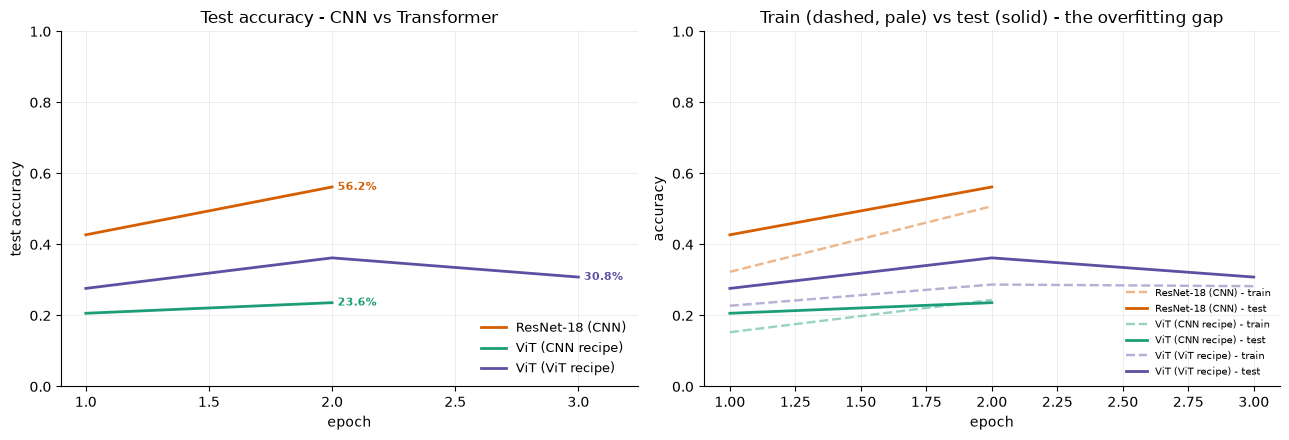

In [19]:
# -- The scoreboard ----------------------------------------------------------------------------------
print(f'{"model":20s} {"params":>11s} {"epochs":>7s} {"best test acc":>14s}   recipe')
print('-' * 100)
for name, r in results.items():
    print(f'{name:20s} {r["params"]:11,d} {r["epochs"]:7d} {r["best_acc"]:13.2%}   {r["recipe"]}')

# One color per MODEL, one line-style per SPLIT.  Keeping those two encodings independent is what
# makes the plot readable: color answers "which model?", dash-vs-solid answers "train or test?".
# Solid + dark = test (the number we care about); dashed + light = train (context for overfitting).
#
# A note on the colors, because picking them naively fails TWICE:
#
#   (1) Pure red + green is the classic colorblind collision.  Under deuteranopia (~6% of men) a
#       standard red and green land ~5 dE apart -- indistinguishable.  So the "red" here is a
#       vermilion and the "green" is a bluish green (the Okabe-Ito colorblind-safe hues).
#   (2) The subtler one: this chart draws SIX marks, not three -- every model has a pale TRAIN line
#       as well as a saturated TEST line.  Pale tints of ADJACENT hues converge.  A true blue
#       (#0072B2) next to this green gives pale tints only ~3 dE apart -- you cannot tell the two
#       ViT train curves apart, even with normal color vision.  Pushing the blue toward VIOLET
#       fixes it and costs nothing.
#
# Validated: worst-case separation over all six marks, under normal vision plus simulated
# protanopia / deuteranopia / tritanopia, is 12.3 dE (12 is the accepted floor; the naive palette
# scored 3.4).  The lesson: validate the marks you actually DRAW, not the palette you think you
# chose.
COLORS = {
    'ResNet-18 (CNN)':  '#D55E00',   # vermilion ("red")
    'ViT (CNN recipe)': '#1B9E77',   # forest green
    'ViT (ViT recipe)': '#5E4FA2',   # violet-blue -- deliberately NOT a true blue; see (2) above
}

def lighten(hex_color, amount=0.55):
    """Mix a color toward white -- the train curves are the same hue, just paler."""
    r, g, b = (int(hex_color[i:i+2], 16) for i in (1, 3, 5))
    mix = lambda c: (c + (255 - c) * amount) / 255
    return (mix(r), mix(g), mix(b))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for name, r in results.items():
    h, c = r['history'], COLORS[name]
    ep = range(1, len(h['test_acc']) + 1)

    # LEFT: test accuracy only -- the head-to-head, uncluttered.
    ax1.plot(ep, h['test_acc'], color=c, linewidth=2, label=name)
    # Direct-label the final point instead of making the reader trace back to the legend.
    ax1.annotate(f'{h["test_acc"][-1]:.1%}', xy=(len(ep), h['test_acc'][-1]),
                 xytext=(4, 0), textcoords='offset points',
                 color=c, fontsize=8, fontweight='bold', va='center')

    # RIGHT: train (pale, dashed) vs test (saturated, solid), same hue per model.  The GAP between
    # a model's two lines is its overfitting; train BELOW test means it is underfit instead.
    ax2.plot(ep, h['train_acc'], color=lighten(c), linewidth=1.75, linestyle='--',
             label=f'{name} - train')
    ax2.plot(ep, h['test_acc'],  color=c,          linewidth=2,
             label=f'{name} - test')

for ax in (ax1, ax2):
    ax.set_xlabel('epoch')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linewidth=0.6)          # recessive grid: present, not shouting
    ax.spines[['top', 'right']].set_visible(False)

ax1.set_ylabel('test accuracy'); ax1.set_title('Test accuracy - CNN vs Transformer')
ax1.legend(loc='lower right', frameon=False, fontsize=9)
ax1.set_xlim(right=max(len(r['history']['test_acc']) for r in results.values()) * 1.08)

ax2.set_ylabel('accuracy'); ax2.set_title('Train (dashed, pale) vs test (solid) - the overfitting gap')
ax2.legend(loc='lower right', frameon=False, fontsize=7.5, ncol=1)

plt.tight_layout(); plt.show()

In [20]:
# -- Clean training accuracy: the apples-to-apples number --------------------------------------------
# STOP AND READ THIS, because the numbers printed during training are a trap.
#
# The `train acc` we printed every epoch is measured on AUGMENTED images -- each one randomly cropped,
# flipped, and (for the ViT) sheared/rotated/posterized by RandAugment.  The `test acc` is measured on
# CLEAN images.  Those are two different exams, and the training one is deliberately harder.  So
# "train accuracy" as printed is NOT comparable to "test accuracy", and the gap between them is not
# the overfitting gap.  With strong enough augmentation the training number can even come out LOWER
# than the test number -- which looks impossible, and is purely an artifact of the measurement.
#
# (A second, smaller effect: the per-epoch train accuracy is a running average accumulated WHILE the
# weights are still updating, whereas test accuracy is measured at the END of the epoch with the final
# weights.  Early in training, when the model improves quickly, that alone drags the train number down.)
#
# The honest measurement is below: run the TRAINING set through the TEST transform (no augmentation),
# in eval() mode.  Now both numbers are the same exam and the difference between them means something:
# it is how much better the model does on data it has seen than on data it has not.  THAT is
# overfitting.  (In 502 this distinction never arose -- get_CIFAR10_data preprocessed everything once,
# up front, so train and val were always scored identically.  Augmentation is what breaks the symmetry.)
clean_train_set    = datasets.CIFAR10(root='./data/cifar10', train=True, download=False, transform=test_tf)
clean_train_loader = DataLoader(clean_train_set, batch_size=512, shuffle=False,
                                num_workers=0, pin_memory=PIN)

print(f'{"model":20s} {"clean train":>12s} {"test":>8s} {"gap":>8s}   read as')
print('-' * 78)
for name, net, dev in [('ResNet-18 (CNN)', model, DEVICE),
                        ('ViT (CNN recipe)', vit_naive, VIT_DEVICE),
                        ('ViT (ViT recipe)', vit_tuned, VIT_DEVICE)]:
    _, clean_train_acc = evaluate(net, clean_train_loader, criterion, dev)
    test_acc = results[name]['best_acc']
    gap = clean_train_acc - test_acc
    if clean_train_acc > 0.98:
        note = 'memorized the training set'
    elif gap > 0.10:
        note = 'overfitting'
    elif clean_train_acc < test_acc + 0.02:
        note = 'UNDERFIT -- capacity unused, train it longer'
    else:
        note = 'healthy'
    print(f'{name:20s} {clean_train_acc:11.2%} {test_acc:8.2%} {gap:+8.2%}   {note}')

print('\nCompare each "clean train" figure with the `train acc` printed during training above:')

print('the difference between those two is the augmentation tax, not a property of the model.')

model                 clean train     test      gap   read as
------------------------------------------------------------------------------


ResNet-18 (CNN)           57.33%   56.18%   +1.15%   UNDERFIT -- capacity unused, train it longer


ViT (CNN recipe)          22.83%   23.60%   -0.77%   UNDERFIT -- capacity unused, train it longer


ViT (ViT recipe)          31.38%   36.22%   -4.84%   UNDERFIT -- capacity unused, train it longer

Compare each "clean train" figure with the `train acc` printed during training above:
the difference between those two is the augmentation tax, not a property of the model.


### Reading the scoreboard

**The ResNet wins.** On 50,000 images, the architecture with locality and translation-equivariance
built in beats the one that has to learn them from data. That is the expected result, it is *not* a
bug in the ViT, and it is the single most important thing on this page.

Three things to take from the rest of it:

**1. Most of the ViT's apparent weakness was the recipe, not the architecture.** Run A and run B are
the *same model* — same 10.7M parameters, same patches, same attention. Not one line of
`make_cifar_vit` changed between them. Everything that moved was the optimizer (SGD → AdamW), the
schedule (adding warmup), the augmentation, and the loss (label smoothing) — and the accuracy moved
enormously. Whenever you read "architecture X is bad at task Y," ask first whether X was trained like
Y's incumbent. Very often that is the whole finding.

**2. The residual gap is inductive bias, and that part is real.** Even properly trained, the ViT
loses to a 20-epoch ResNet while burning far more wall-clock. That residue is the price of having no
locality prior — a price paid in data the ViT does not have. Flip the data scale and the sign of this
result flips with it, which is exactly what §10 is about.

**3. Do not read the train/test gap off the training printout.** The `train acc` printed each epoch is
measured on *augmented* images; `test acc` is measured on *clean* ones. They are two different exams,
and the training one is deliberately harder — so that "gap" is contaminated by the augmentation and,
with strong enough augmentation, the train number can even land **below** the test number. That looks
impossible and it fooled us: it is an artifact of the measurement, not a property of the model. The
**clean training accuracy** cell above is the honest comparison — same exam, both sides — and it is the
only one of the two you should draw conclusions from.

That artifact also has a real lesson buried in it. When we first ran the ViT with the *published*
recipe (`RandAugment(magnitude=9)` + `RandomErasing`, which the literature pairs with **300** epochs)
on a 60-epoch budget, the model came out **underfit** — it never got to use its capacity, because we
were regularizing it harder than it could learn. **Augmentation strength has to be matched to the
epoch budget.** Copying a hyperparameter without copying the schedule it was tuned against is a
genuinely common way to get a bad result and blame the architecture.

> **A note on fairness, stated plainly.** The ViT gets more epochs than the CNN (`VIT_EPOCHS` vs
> `EPOCHS`), because ViTs converge slowly and cutting it off at 20 would understate it. That means
> this is **not** an epoch-matched comparison, and it is not a wall-clock-matched one either — the
> table reports both columns so you can judge it yourself rather than take our word for it. It *is*
> parameter-matched (10.7M vs 11.2M). There is no single "fair" way to compare two architectures that
> want different amounts of compute; the honest move is to say which axis you matched and show the
> rest.

---
